# BePLi v1 YOLO 11 Image Segmentation with Slicing

## Original Dataset Analysis

### Image Size Statistic

In [22]:
import os
from PIL import Image

def get_image_resolutions(directory):
    widths = []
    heights = []
    resolutions = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.gif')):
                filepath = os.path.join(root, file)
                try:
                    with Image.open(filepath) as img:
                        width, height = img.size
                        widths.append(width)
                        heights.append(height)
                        resolutions.append(width * height)
                except Exception as e:
                    print(f"Error opening {filepath}: {e}")
    return widths, heights, resolutions

def main():
    directory = "plastic_coco/images"
    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist.")
        return
    
    widths, heights, resolutions = get_image_resolutions(directory)
    if not widths:
        print("No images found.")
        return
    
    min_width = min(widths)
    max_width = max(widths)
    avg_width = sum(widths) / len(widths)
    
    min_height = min(heights)
    max_height = max(heights)
    avg_height = sum(heights) / len(heights)
    
    avg_resolution = sum(resolutions) / len(resolutions)
    below_avg = sum(1 for r in resolutions if r < avg_resolution)
    above_avg = sum(1 for r in resolutions if r > avg_resolution)
    
    print(f"Minimum image resolution: {min_width} x {min_height}")
    print(f"Average image resolution: {avg_width:.2f} x {avg_height:.2f}")
    print(f"Largest image resolution: {max_width} x {max_height}")
    print(f"Images below average resolution ({avg_resolution:.0f} pixels): {below_avg}")
    print(f"Images above average resolution ({avg_resolution:.0f} pixels): {above_avg}")

if __name__ == "__main__":
    main()

Minimum image resolution: 417 x 313
Average image resolution: 869.95 x 650.00
Largest image resolution: 8192 x 7848
Images below average resolution (773475 pixels): 6630
Images above average resolution (773475 pixels): 822


### COCO JSON Structure

In [2]:
import json

json_file = "plastic_coco/annotation/test.json"

with open(json_file, 'r') as f:
    data = json.load(f)

print("--- TOP LEVEL KEYS ---")
print(list(data.keys()))

print("\n--- SAMPLE IMAGE ENTRY (First Item) ---")
if 'images' in data and len(data['images']) > 0:
    print(json.dumps(data['images'][0], indent=4))
else:
    print("No images found or key is missing.")

print("\n--- SAMPLE ANNOTATION ENTRY (First Item) ---")
if 'annotations' in data and len(data['annotations']) > 0:
    print(json.dumps(data['annotations'][0], indent=4))
else:
    print("No annotations found or key is missing.")

print("\n--- SAMPLE CATEGORY ENTRY (First Item) ---")
if 'categories' in data and len(data['categories']) > 0:
    print(json.dumps(data['categories'][0], indent=4))
else:
    print("No categories found.")

--- TOP LEVEL KEYS ---
['info', 'licenses', 'images', 'annotations', 'categories']

--- SAMPLE IMAGE ENTRY (First Item) ---
{
    "license": 1,
    "file_name": "000001.png",
    "coco_url": "",
    "height": 480,
    "width": 640,
    "date_captured": "",
    "flickr_url": "",
    "id": 1074
}

--- SAMPLE ANNOTATION ENTRY (First Item) ---
{
    "segmentation": {
        "size": [
            480,
            640
        ],
        "counts": "f^]33l>100000O\\Vl5"
    },
    "area": 18,
    "iscrowd": 1,
    "image_id": 1074,
    "bbox": [
        233.0,
        245.0,
        5.0,
        4.0
    ],
    "category_id": 1,
    "id": 38700
}

--- SAMPLE CATEGORY ENTRY (First Item) ---
{
    "supercategory": "plastic_litter",
    "id": 1,
    "name": "plastic_litter"
}


## JSON Cleanup + Slicing + COCO to YOLO Conversion

In [8]:

# ================= CONFIGURATION =================
RAW_DATA_ROOT = "plastic_coco"
TEMP_JSON_DIR = "plastic_coco/temp_fixed_json"
YOLO_OUTPUT_DIR = "plastic_seg_yolo"
NEGATIVES_DIR = "beach_negatives"  # <--- Source of negative images

SLICE_SIZE = 640 
OVERLAP_RATIO = 0.2
MIN_AREA = 16.0 

DATA_SPLITS = [
    ("train", "train.json", "images/train"), 
    ("val",   "val.json",   "images/val"),
    ("test",  "test.json",  "images/test")
]
# =================================================

### 1. JSON Cleanup

Involves:
- getting rid of nonstandard keys
- converting RLE to polygon
- getting rid of very small polygons that cause noise & slice failure

In [9]:
import json
import os
import shutil
import numpy as np
from shapely.geometry import Polygon, MultiPolygon
from shapely.validation import make_valid
from pycocotools import mask as mask_utils
import cv2


def rle_to_polygon(segmentation, height, width):
    """ Converts RLE to Polygon (OpenCV Style). """
    try:
        if isinstance(segmentation, dict) and isinstance(segmentation.get('counts'), str):
            segmentation['counts'] = segmentation['counts'].encode('utf-8')
            binary_mask = mask_utils.decode([segmentation])[:, :, 0]
        elif isinstance(segmentation, dict) and isinstance(segmentation.get('counts'), list):
            rle = mask_utils.frPyObjects(segmentation, height, width)
            binary_mask = mask_utils.decode(rle)
        elif isinstance(segmentation, list):
            rle = mask_utils.frPyObjects(segmentation, height, width)
            binary_mask = mask_utils.decode(rle)
        else:
            return []

        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        polygons = []
        for contour in contours:
            if contour.size >= 6: 
                polygons.append(contour.flatten().tolist())
        return polygons
    except Exception:
        return []

def fix_polygon_geometry(poly):
    """ Magic fix for broken polygons. """
    if not poly.is_valid:
        poly = make_valid(poly)
    
    poly = poly.buffer(0)
    
    if isinstance(poly, MultiPolygon):
        if len(poly.geoms) > 0:
            poly = max(poly.geoms, key=lambda p: p.area)
        else:
            return None
            
    if poly.is_empty or poly.area < MIN_AREA:
        return None
        
    return poly

def scorched_earth_cleaning(annotations):
    clean_anns = []
    fixed_coords = 0
    purged_anns = 0  # Counter for objects deleted due to missing segments
    dropped_small = 0 
    
    for ann in annotations:
        # 1. Sanitize BBox
        if 'bbox' in ann:
            x, y, w, h = ann['bbox']
            if w < 2: w = 2
            if h < 2: h = 2
            ann['bbox'] = [x, y, w, h]
            bbox_area = w * h
        else:
            continue

        # 2. Fix Segmentation
        valid_seg = False
        final_area = bbox_area 
        
        if 'segmentation' in ann and isinstance(ann['segmentation'], list) and len(ann['segmentation']) > 0:
            try:
                raw_coords = ann['segmentation'][0]
                # Check for at least 3 points (6 coords)
                if len(raw_coords) >= 6:
                    pts = np.array(raw_coords).reshape(-1, 2)
                    shapely_poly = Polygon(pts)
                    
                    clean_poly = fix_polygon_geometry(shapely_poly)
                    
                    if clean_poly is not None:
                        new_coords = np.array(clean_poly.exterior.coords).flatten().tolist()
                        ann['segmentation'] = [new_coords]
                        final_area = clean_poly.area
                        valid_seg = True
                        fixed_coords += 1
            except Exception:
                valid_seg = False

        # 3. GLOBAL SIZE CHECK 
        if final_area < MIN_AREA:
            dropped_small += 1
            continue 

        # 4. Finalize Structure (STRICT MODE)
        if valid_seg:
            ann['area'] = final_area
            ann['iscrowd'] = 0
            clean_anns.append(ann)
        else:
            # --- STRICT DELETION ---
            # If valid_seg is False, we completely ignore this annotation.
            # We do NOT append it to clean_anns.
            purged_anns += 1
            continue

    print(f"    - Scorched Earth Report:")
    print(f"      FIXED: {fixed_coords} polygons (geometry repaired)")
    print(f"      DROPPED: {dropped_small} objects (area < {MIN_AREA})")
    print(f"      PURGED: {purged_anns} objects removed (No valid segmentation found)")
    return clean_anns

def inject_negatives(data, target_img_folder):
    """
    Copies images from NEGATIVES_DIR to target_img_folder.
    Adds them to the COCO JSON 'images' list.
    Does NOT add to 'annotations' list (Standard COCO way to define negatives).
    """
    if not os.path.exists(NEGATIVES_DIR):
        print(f"    ! Warning: Negative directory '{NEGATIVES_DIR}' not found. Skipping.")
        return data

    print(f"    + Injecting negatives from: {NEGATIVES_DIR}")
    
    # Calculate starting ID to avoid conflicts
    current_ids = [img['id'] for img in data['images']]
    next_id = (max(current_ids) + 1) if current_ids else 1
    
    neg_files = [f for f in os.listdir(NEGATIVES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    added_count = 0

    for fname in neg_files:
        src_path = os.path.join(NEGATIVES_DIR, fname)
        dst_path = os.path.join(target_img_folder, fname)
        
        # 1. Copy Image File
        try:
            shutil.copy2(src_path, dst_path)
        except Exception as e:
            print(f"      Error copying {fname}: {e}")
            continue

        # 2. Get Dimensions
        img = cv2.imread(src_path)
        if img is None:
            print(f"      Error reading {fname}, skipping.")
            continue
        h, w = img.shape[:2]

        # 3. Add to JSON 'images' list
        data['images'].append({
            "id": next_id,
            "file_name": fname, # Assumes flat directory structure in images/train
            "width": w,
            "height": h,
            "license": 0,
            "date_captured": ""
        })
        
        next_id += 1
        added_count += 1
        
    print(f"      Successfully added {added_count} negative images (Background only).")
    return data

def fix_json_phase1(split_name, json_filename, relative_img_path):
    """ Phase 1: RLE -> Scorched Earth Fix -> Inject Negatives -> Save """
    input_json = os.path.join(RAW_DATA_ROOT, "annotation", json_filename)
    output_json = os.path.join(TEMP_JSON_DIR, json_filename)
    
    print(f"Fixing JSON for {split_name.upper()}...")
    with open(input_json, 'r') as f:
        data = json.load(f)

    # --- NEW: Inject Negatives (Train Only) ---
    if split_name == "train":
        full_train_img_path = os.path.join(RAW_DATA_ROOT, relative_img_path)
        # Ensure directory exists before copying
        os.makedirs(full_train_img_path, exist_ok=True) 
        data = inject_negatives(data, full_train_img_path)
    # ------------------------------------------

    img_dims = {img['id']: (img['height'], img['width']) for img in data['images']}
    processed_anns = []

    # Step A: RLE Conversion
    for ann in data['annotations']:
        if ann['image_id'] not in img_dims: continue
        
        if 'segmentation' in ann and isinstance(ann['segmentation'], dict) and 'counts' in ann['segmentation']:
            polygons = rle_to_polygon(ann['segmentation'], *img_dims[ann['image_id']])
            if polygons:
                ann['segmentation'] = polygons
                processed_anns.append(ann)
        else:
            processed_anns.append(ann)

    # Step B: Scorched Earth Cleaning
    data['annotations'] = scorched_earth_cleaning(processed_anns)
    
    os.makedirs(os.path.dirname(output_json), exist_ok=True)
    with open(output_json, 'w') as f:
        json.dump(data, f)
    
    return output_json

# ================= EXECUTION =================

if os.path.exists(YOLO_OUTPUT_DIR): shutil.rmtree(YOLO_OUTPUT_DIR)
if os.path.exists(TEMP_JSON_DIR): shutil.rmtree(TEMP_JSON_DIR)

# --- PHASE 1 ---
for split, json_file, src_folder in DATA_SPLITS:
    # Updated to pass src_folder (e.g., "images/train")
    fixed_json_path = fix_json_phase1(split, json_file, src_folder)

Fixing JSON for TRAIN...
    + Injecting negatives from: beach_negatives
      Successfully added 34 negative images (Background only).
    - Scorched Earth Report:
      FIXED: 63247 polygons (geometry repaired)
      DROPPED: 2141 objects (area < 16.0)
      PURGED: 8333 objects removed (No valid segmentation found)
Fixing JSON for VAL...
    - Scorched Earth Report:
      FIXED: 19496 polygons (geometry repaired)
      DROPPED: 698 objects (area < 16.0)
      PURGED: 2766 objects removed (No valid segmentation found)
Fixing JSON for TEST...
    - Scorched Earth Report:
      FIXED: 19764 polygons (geometry repaired)
      DROPPED: 340 objects (area < 16.0)
      PURGED: 2164 objects removed (No valid segmentation found)


### 2. Convert Sliced COCO JSON to YOLO txt

In [ ]:
from ultralytics.data.converter import convert_coco

print("\n--- PHASE 3: Generating YOLO Labels ---")

convert_coco(
    labels_dir=TEMP_JSON_DIR,
    save_dir=YOLO_OUTPUT_DIR,
    use_segments=True,
    use_keypoints=False,
)



--- PHASE 3: Generating YOLO Labels ---
Annotations /home/user/projects/ai-plastic-spotter/train/plastic_coco/temp_fixed_json/test.json: 100% ━━━━━━━━━━━━ 737/737 1.5Kit/s 0.5s0.1ss
Annotations /home/user/projects/ai-plastic-spotter/train/plastic_coco/temp_fixed_json/train.json: 100% ━━━━━━━━━━━━ 2215/2215 1.5Kit/s 1.5s0.1s
Annotations /home/user/projects/ai-plastic-spotter/train/plastic_coco/temp_fixed_json/val.json: 100% ━━━━━━━━━━━━ 739/739 1.5Kit/s 0.5s0.1ss
COCO data converted successfully.
Results saved to /home/user/projects/ai-plastic-spotter/train/plastic_seg_yolo


### 3. Symlink Original Sliced Image to YOLO Folder

Symlink: plastic_sliced_yolo/images/* -> plastic_sliced_coco/images/*

In [ ]:
def safe_symlink(split_name, src_subfolder):
    """ 
    Creates a relative symlink.
    Checks if source exists FIRST to prevent broken 'file-like' links.
    """
    # 1. Define paths
    # The actual physical location of the images
    target_abs_path = os.path.abspath(src_subfolder)
    
    # Where we want the link to be
    link_parent = os.path.join(YOLO_OUTPUT_DIR, "images")
    link_path = os.path.join(link_parent, split_name)

    # 2. VALIDATION: Does the source actually exist?
    if not os.path.exists(target_abs_path):
        print(f"  [CRITICAL ERROR] Cannot link '{split_name}'. Source folder not found:")
        print(f"    -> {target_abs_path}")
        print(f"    -> Check 'DATA_SPLITS' config at top of script.")
        return

    # 3. Cleanup existing links
    os.makedirs(link_parent, exist_ok=True)
    if os.path.lexists(link_path): # lexists returns True even for broken links
        if os.path.islink(link_path) or os.path.isfile(link_path):
            os.unlink(link_path)
        else:
            shutil.rmtree(link_path)

    # 4. Create RELATIVE Symlink (More robust in WSL)
    # This creates a link pointing to e.g. "../../../plastic_coco/images/train"
    rel_source = os.path.relpath(target_abs_path, start=link_parent)
    
    print(f"Linking: {link_path} -> {rel_source}")
    try:
        os.symlink(rel_source, link_path)
    except OSError as e:
        print(f"  [Error] Failed to create symlink: {e}")


print("\n--- PHASE 4: Linking Image Folders ---")
for split, _, _ in DATA_SPLITS:
    safe_symlink(split, os.path.join(RAW_DATA_ROOT, "images", split))

print("\nDONE.")


--- PHASE 4: Linking Image Folders ---
Linking: plastic_seg_yolo/images/train -> ../../plastic_coco/images/train
Linking: plastic_seg_yolo/images/val -> ../../plastic_coco/images/val
Linking: plastic_seg_yolo/images/test -> ../../plastic_coco/images/test

DONE.


### Generate Missing YOLO .txt (for negatives/background with no label)

In [ ]:
import os
import glob
from pathlib import Path

def generate_missing_empty_labels(images_dir, labels_dir):
    # 1. Get all image files (jpg, png, jpeg, etc.)
    # Adjust extensions if you use different formats
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(images_dir, ext)))

    print(f"Checking {len(image_files)} images for missing labels...")
    
    created_count = 0
    
    for img_path in image_files:
        # Get the filename without extension (e.g., "slice_01")
        stem = Path(img_path).stem
        
        # Construct expected label path
        label_path = os.path.join(labels_dir, f"{stem}.txt")
        
        # 2. If label file doesn't exist, create it (empty)
        if not os.path.exists(label_path):
            with open(label_path, 'w') as f:
                pass # Create empty file
            created_count += 1

    print(f"--- Fix Complete: Created {created_count} empty label files for background images. ---")

for split, _, _ in DATA_SPLITS:
    print(f"\nProcessing split: {split.upper()}")
    # Define where your actual images and the new labels are located
    # You need to point this to the folder containing the IMAGES corresponding to the labels
    # Assuming standard YOLO structure or your sliced directory:
    imgs_path = os.path.join(YOLO_OUTPUT_DIR, "images", split) # Update this path if your images are elsewhere
    lbls_path = os.path.join(YOLO_OUTPUT_DIR, "labels", split) # default output of convert_coco is often inside a 'labels' subdir

    # Run the fix
    generate_missing_empty_labels(imgs_path, lbls_path)


Processing split: TRAIN
Checking 2260 images for missing labels...
--- Fix Complete: Created 45 empty label files for background images. ---

Processing split: VAL
Checking 742 images for missing labels...
--- Fix Complete: Created 3 empty label files for background images. ---

Processing split: TEST
Checking 741 images for missing labels...
--- Fix Complete: Created 4 empty label files for background images. ---



## Compressing Sliced YOLO Dataset

One might need to compress to save time copying files to cloud GPU.

For compressing this with tar use the `-h` flag:

> tar `-h` flag: 
> *When reading or writing a file to be archived, tar accesses the file that a symbolic link points to, rather than the symlink itself.*

**tar + gunzip**

```sh
tar -hczf plastic_sliced_yolo.tar.gz plastic_sliced_yolo/
```

Extract:

```sh
tar -xzf plastic_sliced_yolo.tar.gz
```

**tar + pigz**

`pigz` is a multithreaded gunzip implementation. Useful if you need faster gunzip compression. Requires `pigz` to be installed.

```sh
tar --use-compress-program=pigz -hcf plastic_sliced_yolo.tar.gz plastic_sliced_yolo/
```

You extract it like you would extract `.tar.gz` file.

**tar + zstd**

`zstd` is a fast modern compression format. Not compatible with gunzip. Requires `zstd` to be installed. It is as fast/faster than `pigz` for less load.

```sh
tar --zstd -hcf plastic_sliced_yolo.tar.zst plastic_sliced_yolo/
```

Extract:

```sh
tar --zstd -xf plastic_sliced_yolo.tar.zst
```


## Inspecting Anomalous Polygons

Found 43 objects.


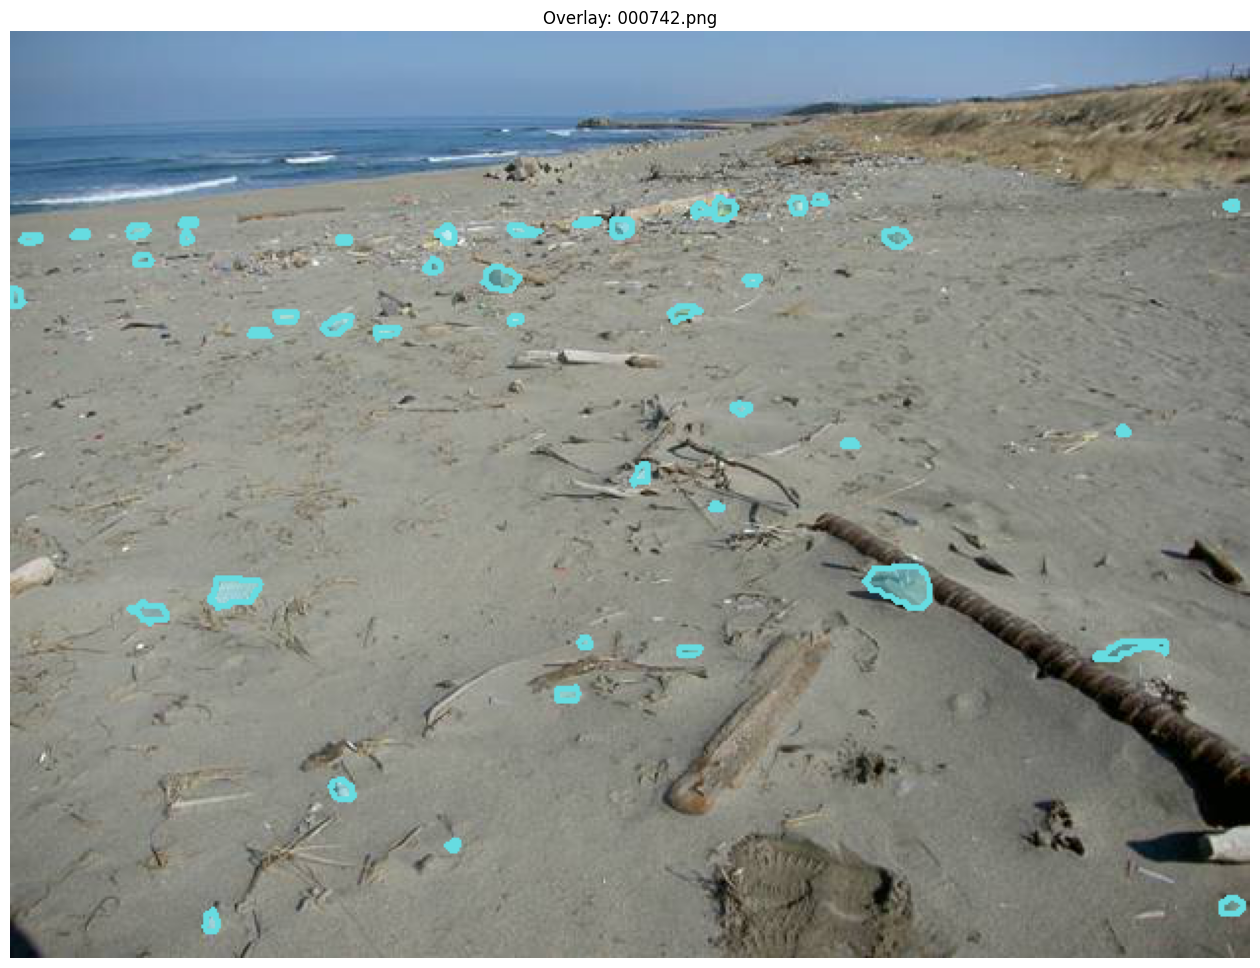

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def visualize_yolo_jupyter(image_path, label_path, figsize=(16, 16), alpha=0.4):
    """
    Visualizes YOLO segmentation on an existing image in Jupyter.
    
    Args:
        image_path (str): Path to the .jpg/.png image.
        label_path (str): Path to the .txt file with segmentation data.
        figsize (tuple): Size of the matplotlib plot (increase for small objects).
        alpha (float): Transparency of the mask (0.0 to 1.0).
    """
    
    # 1. Load and Validate Image
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return
    
    # Load Image (BGR -> RGB)
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not read image file.")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # 2. Read Label File
    lines = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
    else:
        print(f"Warning: Label file not found at {label_path}")

    # Generate consistent random colors for classes
    np.random.seed(42) 
    colors = np.random.randint(0, 255, size=(100, 3), dtype=np.uint8)

    print(f"Found {len(lines)} objects.")

    # 3. Draw Polygons
    for line in lines:
        data = line.strip().split()
        if len(data) < 3: continue # Skip invalid lines

        class_id = int(data[0])
        
        # Parse normalized coordinates
        coords = np.array([float(x) for x in data[1:]])
        
        # Reshape to (N, 2)
        poly_coords = coords.reshape(-1, 2)
        
        # Denormalize (Scale to image dimensions)
        poly_coords[:, 0] *= w
        poly_coords[:, 1] *= h
        
        # Convert to int32 for OpenCV
        poly_coords = poly_coords.astype(np.int32)
        pts = poly_coords.reshape((-1, 1, 2))

        # Get Color
        color = [int(c) for c in colors[class_id]] # RGB

        # A. Draw Semi-Transparent Fill
        overlay = img_rgb.copy()
        cv2.fillPoly(overlay, [pts], color)
        img_rgb = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)
        
        # B. Draw Border (Crucial for small objects to see edges)
        # Thickness 1 or 2 is usually best for small objects
        cv2.polylines(img_rgb, [pts], isClosed=True, color=color, thickness=2)

    # 4. Plot
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Overlay: {os.path.basename(image_path)}")
    plt.show()

# ==========================================
# PASTE YOUR PATHS BELOW
# ==========================================

# Example: "dataset/images/train/img_001.jpg"
img_path = "plastic_seg_yolo/images/train/000742.png" 

# Example: "dataset/labels/train/img_001.txt"
txt_path = "plastic_seg_yolo/labels/train/000742.txt" 

visualize_yolo_jupyter(img_path, txt_path)

In [18]:
import json

# Path to your RAW train.json
json_path = "plastic_coco/temp_fixed_json/train.json"

with open(json_path, 'r') as f:
    data = json.load(f)

# 1. Get the 187th Image (Index 186)
# Note: SAHI iterates images in the order they appear in 'images' list
if len(data['images']) > 186:
    target_img = data['images'][186]
    print(f"--- SUSPECT IMAGE (Index 186) ---")
    print(f"ID: {target_img['id']}")
    print(f"File: {target_img['file_name']}")
    print(f"Dims: {target_img['width']}x{target_img['height']}")
    
    # 2. Find annotations for this image
    anns = [a for a in data['annotations'] if a['image_id'] == target_img['id']]
    print(f"Found {len(anns)} annotations.")
    
    # 3. Inspect them
    for i, ann in enumerate(anns):
        print(ann)
        print(f"\n[Annotation {i}] ID: {ann['id']}")
        print(f"  - BBox: {ann.get('bbox')}")
        print(f"  - Area (in JSON): {ann.get('area')}")
        print(f"  - Iscrowd: {ann.get('iscrowd')}")
        
        # Check Segmentation
        seg = ann.get('segmentation')
        if not seg:
            print("  - Segmentation: NONE/EMPTY")
        elif isinstance(seg, dict):
             print(f"  - Segmentation: RLE (Counts len: {len(seg.get('counts', ''))})")
        elif isinstance(seg, list):
             # Check if it looks like a line
             points = len(seg[0]) if len(seg) > 0 else 0
             print(f"  - Segmentation: POLYGON (Points: {points})")
             if points < 6:
                 print("    [WARNING] Polygon has < 3 points (Invalid!)")
else:
    print("Dataset has fewer than 186 images.")

--- SUSPECT IMAGE (Index 186) ---
ID: 3696
File: 001163.png
Dims: 1600x1200
Found 19 annotations.
{'segmentation': [[1553.0, 648.0, 1551.0, 650.0, 1551.0, 651.0, 1548.0, 654.0, 1548.0, 655.0, 1547.0, 656.0, 1547.0, 660.0, 1546.0, 661.0, 1546.0, 674.0, 1561.0, 689.0, 1563.0, 689.0, 1564.0, 690.0, 1565.0, 690.0, 1566.0, 691.0, 1567.0, 691.0, 1568.0, 692.0, 1569.0, 692.0, 1570.0, 693.0, 1572.0, 693.0, 1573.0, 694.0, 1574.0, 694.0, 1575.0, 695.0, 1576.0, 695.0, 1577.0, 696.0, 1579.0, 696.0, 1580.0, 697.0, 1581.0, 697.0, 1582.0, 698.0, 1583.0, 698.0, 1584.0, 699.0, 1586.0, 699.0, 1587.0, 700.0, 1588.0, 700.0, 1589.0, 701.0, 1590.0, 701.0, 1592.0, 703.0, 1593.0, 703.0, 1594.0, 704.0, 1595.0, 704.0, 1597.0, 706.0, 1598.0, 706.0, 1599.0, 707.0, 1599.0, 652.0, 1595.0, 652.0, 1594.0, 653.0, 1587.0, 653.0, 1586.0, 652.0, 1583.0, 652.0, 1582.0, 651.0, 1578.0, 651.0, 1577.0, 650.0, 1572.0, 650.0, 1571.0, 649.0, 1566.0, 649.0, 1565.0, 648.0, 1553.0, 648.0]], 'area': 2225.0, 'iscrowd': 0, 'image_id':

In [19]:
import os
from pathlib import Path

# ================= CONFIGURATION =================
# Replace this with the path to your labels folder
TARGET_DIRS = ["plastic_seg_yolo/labels/train", "plastic_seg_yolo/labels/val", "plastic_seg_yolo/labels/test"]
# =================================================

def scan_labels(directory):
    path = Path(directory)
    
    # Check if directory exists
    if not path.exists():
        print(f"❌ Error: The directory '{directory}' does not exist.")
        print("   Please check the TARGET_DIR path.")
        return

    # Find all .txt files recursively (looks inside subfolders too)
    all_txt_files = list(path.rglob("*.txt"))
    total_files = len(all_txt_files)
    
    empty_files = []
    non_empty_count = 0
    
    print(f"📂 Scanning {total_files} label files in: {path.absolute()}...\n")

    for file_path in all_txt_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                # .strip() removes spaces/newlines. 
                # If content becomes "", the file is effectively empty to YOLO.
                content = f.read().strip()
                
                if not content:
                    empty_files.append(file_path.name)
                else:
                    non_empty_count += 1
                    
        except Exception as e:
            print(f"⚠️ Could not read file {file_path.name}: {e}")

    # --- DISPLAY RESULTS ---
    empty_count = len(empty_files)
    
    print("="*40)
    print("           SCAN RESULTS           ")
    print("="*40)
    print(f"Total .txt Files:      {total_files}")
    print(f"✅ Non-Empty (Objects): {non_empty_count}")
    print(f"🈳 Empty (Background):  {empty_count}")
    
    if total_files > 0:
        percent = (empty_count / total_files) * 100
        print(f"📊 Background Ratio:    {percent:.2f}%")
        
        # --- INTELLIGENT ADVICE ---
        print("-" * 40)
        if percent == 0:
            print("🚨 CRITICAL: You have 0% negative samples.")
            print("   Action: Add ~50-100 empty .txt files to fix false positives.")
        elif percent < 1.0:
            print("⚠️ WARNING: Very low background ratio (<1%).")
            print("   Your model might still hallucinate objects.")
        elif 1.0 <= percent <= 10.0:
            print("✅ GOOD: You have a healthy mix of negative samples.")
        else:
            print("ℹ️ NOTE: High background ratio. Ensure this is intentional.")
    
    return empty_files


for dir in TARGET_DIRS:
    # Run the function
    empty_list = scan_labels(dir)

    # Optional: See the names of the first 5 empty files
    if empty_list:
        print("\nExample empty files found:")
        print(empty_list[:5])

📂 Scanning 2260 label files in: /home/user/projects/ai-plastic-spotter/train/plastic_seg_yolo/labels/train...

           SCAN RESULTS           
Total .txt Files:      2260
✅ Non-Empty (Objects): 2215
🈳 Empty (Background):  45
📊 Background Ratio:    1.99%
----------------------------------------
✅ GOOD: You have a healthy mix of negative samples.

Example empty files found:
['walter-martin-J3mE90e93uM-unsplash.txt', '000964.txt', 'karl-galamiton-6xiD2_dgYqY-unsplash.txt', 'aurora-murgea-JILw0Xin_ok-unsplash.txt', 'max-zaharenkov-ZlLw7Neafzo-unsplash.txt']
📂 Scanning 742 label files in: /home/user/projects/ai-plastic-spotter/train/plastic_seg_yolo/labels/val...

           SCAN RESULTS           
Total .txt Files:      742
✅ Non-Empty (Objects): 739
🈳 Empty (Background):  3
📊 Background Ratio:    0.40%
----------------------------------------
⚠️ WARNING: Very low background ratio (<1%).
   Your model might still hallucinate objects.

Example empty files found:
['002194.txt', '002421.tx

## Train Prep

### Intel (XPU)

In [2]:
import torch

print(f"PyTorch Version: {torch.__version__}")

print(f"XPU Available: {torch.xpu.is_available()}")

if torch.xpu.is_available():
    print(f"Current GPU: {torch.xpu.get_device_name(0)}")

device_str = 'xpu' if torch.xpu.is_available() else 'cpu'
device = torch.device('xpu' if torch.xpu.is_available() else 'cpu')

# Ultralytics has hardcoded CUDA calls that break on XPU
# Monkey-patch functions to work with XPU
import torch
from ultralytics import YOLO
import ultralytics.engine.trainer as trainer_module
import ultralytics.engine.validator as validator_module
import ultralytics.utils.torch_utils as torch_utils_module
import ultralytics.utils.checks as checks_module
import ultralytics.utils as utils_module
import gc

def _get_memory_xpu(self, fraction=False):
    """XPU-compatible memory getter."""
    memory = torch.xpu.memory_reserved() if hasattr(torch.xpu, 'memory_reserved') else 0
    if fraction:
        return 0.1  # Return low fraction to skip memory clearing
    return memory / 2**30

def _clear_memory_xpu(self, threshold=0.5):
    """XPU-compatible memory clearing."""
    gc.collect()
    if hasattr(torch.xpu, 'empty_cache'):
        torch.xpu.empty_cache()

# Patch the select_device function to handle XPU
_original_select_device = torch_utils_module.select_device

def select_device_xpu(device="", newline=False, verbose=True):
    """XPU-aware device selector."""
    device_str = str(device).strip().lower()
    if device_str == "xpu" or (hasattr(device, 'type') and device.type == 'xpu'):
        if torch.xpu.is_available():
            return torch.device('xpu')
    return _original_select_device(device, newline, verbose)

# Patch check_amp to avoid CUDA-only probing on non-CUDA builds (XPU/CPU)
_original_check_amp = checks_module.check_amp

def check_amp_safe(model):
    try:
        if hasattr(torch, "xpu") and torch.xpu.is_available():
            return False
        if not torch.cuda.is_available():
            return False
    except Exception:
        return False
    return _original_check_amp(model)

checks_module.check_amp = check_amp_safe
# BaseTrainer imports check_amp into its module namespace, so patch there too
trainer_module.check_amp = check_amp_safe

# Apply all patches
trainer_module.BaseTrainer._get_memory = _get_memory_xpu
trainer_module.BaseTrainer._clear_memory = _clear_memory_xpu

# Patch select_device everywhere it's imported
torch_utils_module.select_device = select_device_xpu
trainer_module.select_device = select_device_xpu
validator_module.select_device = select_device_xpu

# Also patch in ultralytics.utils (where it might be imported from)
utils_module.torch_utils.select_device = select_device_xpu

PyTorch Version: 2.9.1+xpu
XPU Available: True
Current GPU: Intel(R) Graphics [0x64a0]


### NVIDIA (CUDA)

In [ ]:
from ultralytics import YOLO

## Train

In [3]:
# "-seg" is crucial! It tells YOLO to learn masks, not just boxes.
model = YOLO("yolo11n-seg.pt") 

# intel moment.
# Ultralytics uses AMP auto-checks that hard-require CUDA; disable AMP on XPU/CPU builds
amp_flag = False if device_str in {'xpu', 'cpu'} else True

results = model.train(
    data="bepliv1_seg.yml",
    project="plastic_project",
    name="11n-seg",
    
    # device=[0,1,2,3],
    # workers=32,
    batch=16,
    
    epochs=1,#150, 
    patience=50,
    
    mosaic=1.0,           
    close_mosaic=20,      
    
    copy_paste=0.3,       
    
    imgsz=1024,
    
    val=True,
    save=True,
    plots=True,
    
    # intel moment.
    device=device_str,
    amp=amp_flag,
)


New https://pypi.org/project/ultralytics/8.3.246 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bepliv1_seg.yml, degrees=0.0, deterministic=True, device=xpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=11n-seg4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=

KeyboardInterrupt: 

## Test

In [2]:
model = YOLO("11m-seg-final2/weights/best.pt")  # Load best model from training
metrics = model.val()
print(f"mAP50-95 (Box): {metrics.box.map}")
print(f"mAP50-95 (Mask): {metrics.seg.map}")


Ultralytics 8.3.241 🚀 Python-3.12.3 torch-2.9.1+xpu CPU (Intel Core Ultra 7 258V)
YOLO11m-seg summary (fused): 138 layers, 22,336,083 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 622.1±118.1 MB/s, size: 626.0 KB)
val: Scanning /home/user/projects/ai-plastic-spotter/train/plastic_sliced_yolo/labels/val... 2269 images, 285 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2269/2269 636.9it/s 3.6s0.1s
val: New cache created: /home/user/projects/ai-plastic-spotter/train/plastic_sliced_yolo/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 8% ━─────────── 12/142 12.1s/it 1:50<26:136


KeyboardInterrupt: 

In [ ]:
import os
from pathlib import Path
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions
from IPython.display import Image, display

# 1. Setup
best_weights = '11m-seg-final2/weights/best.pt'
image_files = ['beach1.jpg', 'beach2.jpg', 'beach3.jpg'] 
output_dir = "sahi_output"

os.makedirs(output_dir, exist_ok=True)

# 2. Load Model
detection_model = AutoDetectionModel.from_pretrained(
    model_type='yolo11-seg', 
    model_path=best_weights,
    confidence_threshold=0.6, 
    device="xpu" 
)

for img_path in image_files:
    if not os.path.exists(img_path):
        print(f"Skipping {img_path}...")
        continue

    print(f"Processing {img_path}...")
    
    # 3. Sliced Prediction
    result = get_sliced_prediction(
        img_path,
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )
    
    # 4. Save to Disk (The Fix)
    # We export the visualization to a real file first.
    save_path = os.path.join(output_dir, Path(img_path).name)
    
    result.export_visuals(export_dir=output_dir, file_name=Path(img_path).stem)
    
    # Note: SAHI saves as {stem}.png, so we reconstruct the path
    saved_file_path = os.path.join(output_dir, Path(img_path).stem + ".png")
    
    print(f" -> Found {len(result.object_prediction_list)} objects.")
    print(f" -> Saved to: {saved_file_path}")

    # 5. Force Display in Notebook
    # This reads the file from disk and forces the notebook to show it
    display(Image(filename=saved_file_path))